<a href="https://colab.research.google.com/github/Castlebin/d2l-zh-pytorch-colab/blob/my_master/9_d2l-zh-pytorch-colab-reorg/03_%E7%BA%BF%E6%80%A7%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/02_Softmax%E5%9B%9E%E5%BD%92%E4%B8%8E%E5%9B%BE%E5%83%8F%E5%88%86%E7%B1%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Softmax回归与图像分类

本notebook介绍分类问题和Softmax回归:
- Fashion-MNIST图像分类数据集
- Softmax回归的原理
- 从零开始实现Softmax回归
- 使用PyTorch的简洁实现

这是深度学习中第一个真正的分类任务!

In [1]:
# 让 matplotlib 绘图可以直接支持中文，安装一下下面这个包
!pip install matplotlib_cn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 1.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for matplotlib_cn: filename=matplotlib_cn-1.0.4-py3-none-any.whl size=5294725 sha256=282d6fa072d925a199f653f682e2d49e5d59a420f2064a120e32460e76b2bae7
  Stored in directory: /root/.cache/pip/wheels/96/8c/13/e82ae20295b23f53bea146b7e8f15dc39df68ef136502e8033
Successfully built matplotlib_cn


In [2]:
# 让 matplotlib 绘图支持中文
from matplotlib_cn import matplotlib_util
matplotlib_util.enable_chinese()

[matplotlib_cn] matplotlib enabled with Chinese font: SimHei 


In [3]:
# 判断当前环境是否是 Google Colab
def is_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


In [4]:
if is_colab():
    print("Running on Google Colab")
else:
    print("Not Colab")


Running on Google Colab


In [5]:
import os

def get_base_data_dir():
    """获取存储数据的 base 目录"""
    if is_colab():
        print("当前环境为 Google Colab, 正在加载 Google Drive...")
        from google.colab import drive
        # 尝试挂载Google Drive，如果已经挂载则不重复操作
        if not os.path.exists('/content/drive'):
            drive.mount('/content/drive')

        # 定义Google Drive中的数据目录路径
        base_dir = os.path.join('/content/drive', 'MyDrive', 'data')
        # 如果目录不存在，则创建它
        os.makedirs(base_dir, exist_ok=True)
        print(f"Google Drive 数据目录已准备就绪: {base_dir}")
        return base_dir
    else:
        print("当前环境不是 Google Colab, 使用本地数据目录。")
        # 使用用户的主目录作为数据存储的根目录
        base_dir = os.path.join(os.path.expanduser('~'), 'data')
        os.makedirs(base_dir, exist_ok=True)
        print(f"本地数据目录已准备就绪: {base_dir}")
        return base_dir

# 示例调用
base_data_directory = get_base_data_dir()
print(f"数据将存储在: {base_data_directory}")


当前环境为 Google Colab, 正在加载 Google Drive...
Mounted at /content/drive
Google Drive 数据目录已准备就绪: /content/drive/MyDrive/data
数据将存储在: /content/drive/MyDrive/data


In [6]:
# 刷盘
if is_colab():
    from google.colab import drive

    drive.flush_and_unmount()
    print('Google Drive 已刷盘')

Google Drive 已刷盘


In [7]:
if is_colab():
    from google.colab import drive
    print(dir(drive))

['_Environment', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_collections', '_env', '_logs_dir', '_message', '_mount', '_os', '_output', '_popen_spawn', '_psutil', '_signal', '_socket', '_subprocess', '_sys', '_timeouts_path', '_uuid', 'flush_and_unmount', 'mount']


In [8]:
drive??

In [9]:
def flush_drive():
    if is_colab():
        from google.colab import drive
        drive.flush_and_unmount()
        print('Google Drive 已刷盘')

flush_drive()

Drive not mounted, so nothing to flush and unmount.
Google Drive 已刷盘


## 第一部分: Fashion-MNIST数据集

### 1.1 数据集简介

**Fashion-MNIST**是一个服饰图像数据集:
- **10个类别**: T恤、裤子、套衫、连衣裙、外套、凉鞋、衬衫、运动鞋、包、短靴
- **训练集**: 60,000张图像
- **测试集**: 10,000张图像
- **图像尺寸**: 28×28像素,灰度图(单通道)

相比MNIST手写数字数据集,Fashion-MNIST更具挑战性,更接近实际应用。

In [10]:
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt

### 1.2 下载和加载数据集

In [11]:
base_data_directory = get_base_data_dir()

当前环境为 Google Colab, 正在加载 Google Drive...
Mounted at /content/drive
Google Drive 数据目录已准备就绪: /content/drive/MyDrive/data


In [12]:
datasets_dir = os.path.join(base_data_directory, 'ML', 'Datasets')
os.makedirs(datasets_dir, exist_ok=True)
print(f'数据集目录: {datasets_dir}')

数据集目录: /content/drive/MyDrive/data/ML/Datasets


In [13]:
# ToTensor将图像转换为张量,并归一化到[0,1]
trans = transforms.ToTensor()

# 下载训练集和测试集
mnist_train = torchvision.datasets.FashionMNIST(
    root=datasets_dir, train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root=datasets_dir, train=False, transform=trans, download=True)

print(f'训练集大小: {len(mnist_train)}')
print(f'测试集大小: {len(mnist_test)}')
print(f'图像形状: {mnist_train[0][0].shape}')

100%|██████████| 26.4M/26.4M [00:03<00:00, 7.98MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 192kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.52MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 34.3MB/s]


训练集大小: 60000
测试集大小: 10000
图像形状: torch.Size([1, 28, 28])


### 1.3 可视化数据

In [14]:
def get_fashion_mnist_labels(labels):
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['T恤', '裤子', '套衫', '连衣裙', '外套',
                   '凉鞋', '衬衫', '运动鞋', '包', '短靴']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        ax.imshow(img.squeeze().numpy(), cmap='gray')
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i], fontproperties='SimHei')
    plt.tight_layout()
    return axes

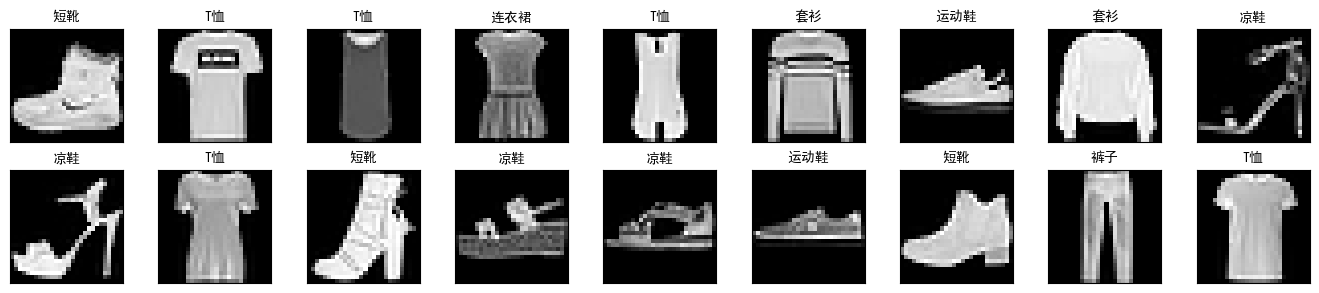

In [15]:
# 显示前18个样本
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(X, 2, 9, titles=get_fashion_mnist_labels(y))
plt.show()

### 1.4 创建数据迭代器

In [16]:
batch_size = 256

# 创建数据加载器
train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=4)
test_iter = data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=4)

print(f'每个批次的形状:')
for X, y in train_iter:
    print(f'  X: {X.shape}, dtype: {X.dtype}')
    print(f'  y: {y.shape}, dtype: {y.dtype}')
    break

每个批次的形状:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


  X: torch.Size([256, 1, 28, 28]), dtype: torch.float32
  y: torch.Size([256]), dtype: torch.int64


---

## 第二部分: Softmax回归理论

### 2.1 从回归到分类

**回归 vs 分类**:
- **回归**: 预测连续值(如房价)
- **分类**: 预测离散类别(如图像类别)

### 2.2 独热编码(One-Hot Encoding)

将类别表示为向量,只有对应类别的位置为1,其余为0:
- 类别0: [1, 0, 0, ..., 0]
- 类别1: [0, 1, 0, ..., 0]
- 类别9: [0, 0, 0, ..., 1]

### 2.3 Softmax回归模型

**网络结构**: 输入 → 全连接层 → Softmax → 输出概率

**数学表达**:
1. 线性变换: $\mathbf{o} = \mathbf{W}\mathbf{x} + \mathbf{b}$
2. Softmax函数: $\hat{y}_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$

**Softmax的性质**:
- 所有输出都在(0, 1)之间
- 所有输出之和为1
- 可以解释为概率分布

### 2.4 交叉熵损失

$$L = -\sum_{j=1}^{q} y_j \log \hat{y}_j$$

其中$y$是真实标签(独热编码),$\hat{y}$是预测概率。

---

## 第三部分: 从零开始实现Softmax回归

In [17]:
import torch
from IPython import display

### 3.1 初始化模型参数

In [18]:
num_inputs = 784  # 28 * 28
num_outputs = 10  # 10个类别

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

print(f'权重W形状: {W.shape}')
print(f'偏置b形状: {b.shape}')

权重W形状: torch.Size([784, 10])
偏置b形状: torch.Size([10])


### 3.2 定义Softmax函数

In [19]:
def softmax(X):
    """Softmax函数"""
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition  # 广播机制

# 测试softmax
X_test = torch.normal(0, 1, (2, 5))
X_prob = softmax(X_test)
print('输入:')
print(X_test)
print('\nSoftmax输出(概率):')
print(X_prob)
print('\n每行的和:', X_prob.sum(1))

输入:
tensor([[-0.2176,  0.2550,  0.3700,  0.3206,  0.5111],
        [ 0.9306,  0.1858, -0.3780, -0.6622,  0.2036]])

Softmax输出(概率):
tensor([[0.1221, 0.1959, 0.2198, 0.2092, 0.2531],
        [0.4112, 0.1953, 0.1111, 0.0836, 0.1988]])

每行的和: tensor([1., 1.])


### 3.3 定义模型

In [20]:
def net(X):
    """Softmax回归模型"""
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

### 3.4 定义交叉熵损失函数

In [21]:
def cross_entropy(y_hat, y):
    """交叉熵损失函数"""
    return -torch.log(y_hat[range(len(y_hat)), y])

# 测试
y_test = torch.tensor([0, 2])
y_hat_test = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
print('交叉熵损失:', cross_entropy(y_hat_test, y_test))

交叉熵损失: tensor([2.3026, 0.6931])


### 3.5 计算分类准确率

In [22]:
def accuracy(y_hat, y):
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

# 测试
print('准确预测数量:', accuracy(y_hat_test, y_test))
print('准确率:', accuracy(y_hat_test, y_test) / len(y_test))

准确预测数量: 1.0
准确率: 0.5


### 3.6 评估模型准确率

In [23]:
def evaluate_accuracy(net, data_iter):
    """计算在指定数据集上模型的准确率"""
    metric = [0.0, 0.0]  # 正确预测数、总数
    with torch.no_grad():
        for X, y in data_iter:
            metric[0] += accuracy(net(X), y)
            metric[1] += y.numel()
    return metric[0] / metric[1]

### 3.7 训练模型

In [24]:
def train_epoch(net, train_iter, loss, updater):
    """训练一个迭代周期"""
    metric = [0.0, 0.0, 0.0]  # 训练损失总和、训练准确度总和、样本数

    for X, y in train_iter:
        # 计算梯度并更新参数
        y_hat = net(X)
        l = loss(y_hat, y)

        if isinstance(updater, torch.optim.Optimizer):
            # 使用PyTorch内置的优化器
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 使用定制的优化器
            l.sum().backward()
            updater(X.shape[0])

        metric[0] += float(l.sum())
        metric[1] += float(accuracy(y_hat, y))
        metric[2] += y.numel()

    # 返回训练损失和训练准确率
    return metric[0] / metric[2], metric[1] / metric[2]

In [25]:
def updater(batch_size):
    """SGD优化器"""
    return torch.optim.SGD([W, b], lr=0.1)

# 或者手动实现SGD
lr = 0.1

def sgd_updater(batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in [W, b]:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [26]:
def train(net, train_iter, test_iter, loss, num_epochs, updater):
    """训练模型"""
    train_losses, train_accs, test_accs = [], [], []

    for epoch in range(num_epochs):
        train_metrics = train_epoch(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)

        train_losses.append(train_metrics[0])
        train_accs.append(train_metrics[1])
        test_accs.append(test_acc)

        print(f'epoch {epoch + 1}, '
              f'loss {train_metrics[0]:.3f}, '
              f'train acc {train_metrics[1]:.3f}, '
              f'test acc {test_acc:.3f}')

    return train_losses, train_accs, test_accs

In [27]:
# 开始训练
num_epochs = 10
train_losses, train_accs, test_accs = train(
    net, train_iter, test_iter, cross_entropy, num_epochs, sgd_updater)

/tmp/ipython-input-452939663.py:20: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  metric[0] += float(l.sum())


epoch 1, loss 0.787, train acc 0.749, test acc 0.756
epoch 2, loss 0.571, train acc 0.813, test acc 0.782
epoch 3, loss 0.525, train acc 0.826, test acc 0.821
epoch 4, loss 0.502, train acc 0.833, test acc 0.821
epoch 5, loss 0.486, train acc 0.836, test acc 0.825
epoch 6, loss 0.474, train acc 0.841, test acc 0.823
epoch 7, loss 0.465, train acc 0.842, test acc 0.811
epoch 8, loss 0.458, train acc 0.845, test acc 0.828
epoch 9, loss 0.451, train acc 0.849, test acc 0.831
epoch 10, loss 0.448, train acc 0.848, test acc 0.832


**可视化训练过程**

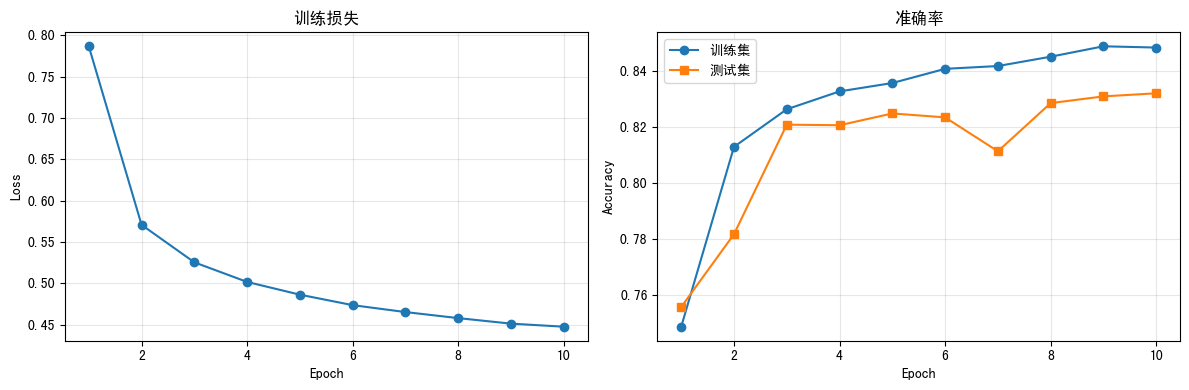

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
ax1.plot(range(1, num_epochs + 1), train_losses, marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('训练损失')
ax1.grid(True, alpha=0.3)

# 准确率曲线
ax2.plot(range(1, num_epochs + 1), train_accs, marker='o', label='训练集')
ax2.plot(range(1, num_epochs + 1), test_accs, marker='s', label='测试集')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('准确率')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.8 预测

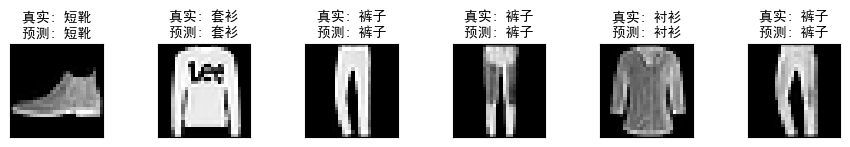

In [29]:
def predict(net, test_iter, n=6):
    """预测标签"""
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [f'真实: {true}\n预测: {pred}'
              for true, pred in zip(trues, preds)]
    show_images(X[0:n], 1, n, titles=titles[0:n])
    plt.show()

predict(net, test_iter)

---

## 第四部分: 使用PyTorch的简洁实现

In [30]:
import torch
from torch import nn
from torch.nn import functional as F

### 4.1 定义模型

In [31]:
# PyTorch不会隐式地调整输入的形状,所以需要flatten
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 10)
)

# 初始化权重
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

print('模型结构:')
print(net)

模型结构:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)


### 4.2 定义损失函数

PyTorch的`CrossEntropyLoss`结合了Softmax和交叉熵,数值更稳定。

In [32]:
loss = nn.CrossEntropyLoss(reduction='none')
print('损失函数:', loss)

损失函数: CrossEntropyLoss()


### 4.3 定义优化算法

In [33]:
trainer = torch.optim.SGD(net.parameters(), lr=0.1)
print('优化器:', trainer)

优化器: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


### 4.4 训练模型

In [34]:
num_epochs = 10
train_losses_c, train_accs_c, test_accs_c = train(
    net, train_iter, test_iter, loss, num_epochs, trainer)

epoch 1, loss 0.788, train acc 0.749, test acc 0.783
epoch 2, loss 0.571, train acc 0.813, test acc 0.810
epoch 3, loss 0.525, train acc 0.826, test acc 0.818
epoch 4, loss 0.502, train acc 0.832, test acc 0.822
epoch 5, loss 0.485, train acc 0.837, test acc 0.823
epoch 6, loss 0.474, train acc 0.841, test acc 0.822
epoch 7, loss 0.465, train acc 0.843, test acc 0.825
epoch 8, loss 0.458, train acc 0.845, test acc 0.829
epoch 9, loss 0.452, train acc 0.847, test acc 0.814
epoch 10, loss 0.448, train acc 0.847, test acc 0.833


**可视化对比**

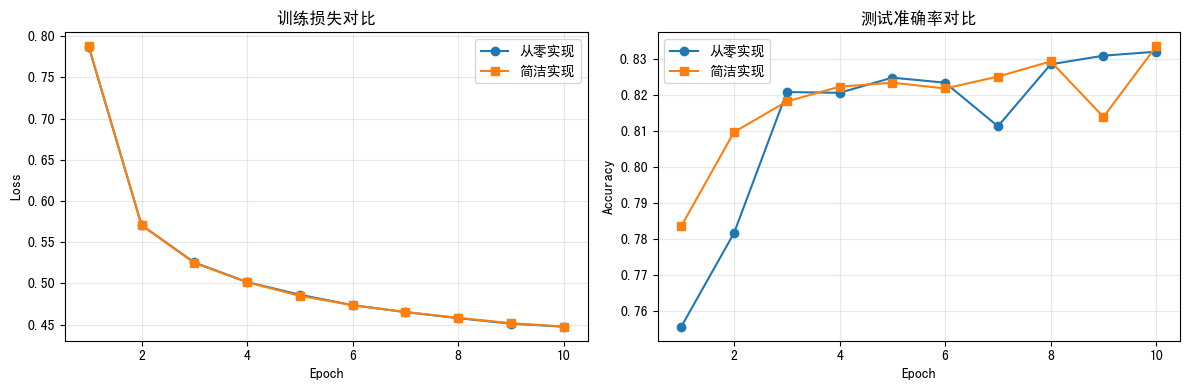

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 损失对比
ax1.plot(range(1, num_epochs + 1), train_losses, marker='o', label='从零实现')
ax1.plot(range(1, num_epochs + 1), train_losses_c, marker='s', label='简洁实现')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('训练损失对比')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 测试准确率对比
ax2.plot(range(1, num_epochs + 1), test_accs, marker='o', label='从零实现')
ax2.plot(range(1, num_epochs + 1), test_accs_c, marker='s', label='简洁实现')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('测试准确率对比')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5 预测

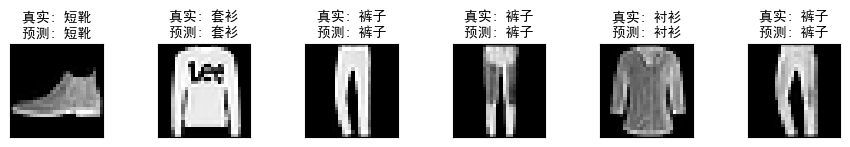

In [36]:
predict(net, test_iter)

### 完成后刷一下盘，保险

In [37]:
flush_drive()

Google Drive 已刷盘


---

## 小结

### 核心概念

1. **分类问题**: 预测离散的类别标签
2. **Softmax函数**: 将实数转换为概率分布
   $$\text{softmax}(\mathbf{x})_i = \frac{\exp(x_i)}{\sum_j \exp(x_j)}$$
3. **交叉熵损失**: 衡量两个概率分布的差异
   $$H(y, \hat{y}) = -\sum_i y_i \log \hat{y}_i$$
4. **独热编码**: 将类别表示为向量

### Fashion-MNIST数据集

- 10个服饰类别
- 60,000训练样本 + 10,000测试样本
- 28×28灰度图像

### 从零实现 vs 简洁实现

| 组件 | 从零实现 | 简洁实现 |
|------|----------|----------|
| 模型 | 手动matmul | `nn.Linear` |
| Softmax | 手动实现 | 内置在`CrossEntropyLoss` |
| 损失函数 | 手动实现 | `nn.CrossEntropyLoss` |
| 优化器 | 手动SGD | `torch.optim.SGD` |

### 性能指标

- **训练准确率**: ~85%
- **测试准确率**: ~83%
- 简单的线性模型在Fashion-MNIST上能达到不错的效果!

## 练习

1. **修改批量大小**: 尝试不同的batch_size(32, 128, 512),观察训练速度和准确率
2. **调整学习率**: 测试不同的学习率(0.01, 0.05, 0.2),找到最优值
3. **增加训练轮数**: 训练20个epoch,观察是否过拟合
4. **混淆矩阵**: 实现混淆矩阵,分析哪些类别容易混淆
5. **数据增强**: 尝试随机旋转、翻转等数据增强技术
6. **其他优化器**: 使用Adam、RMSprop等优化器并比较效果
7. **权重可视化**: 可视化学到的权重矩阵W,看看模型学到了什么
8. **迁移到CIFAR-10**: 将代码应用到CIFAR-10数据集(彩色图像)